In [ ]:
"This notebook is for calculating single cell RNA velocity with Dynamo."

In [1]:
import dynamo as dyn
import numpy as np
from scipy import stats,signal
from matplotlib import pyplot as plt
from scipy import sparse
from sklearn.neighbors import KernelDensity
import networkx as nx
import os
from numpy.random import randint

In [2]:
result_path='result/'
gene_arr=np.load(result_path+'EG_bin_genes.npy',allow_pickle=True)
dim_n=10
adata=dyn.read(result_path+'EG_ori_bin.h5ad')

/home/csb/Saloni/CPT_GRN_analysis/.venv/lib/python3.10/site-packages/anndata/__init__.py:55: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [7]:
import dynamo as dyn
import pandas as pd
import polars as pl

print(dyn.__version__)
print(pd.__version__)
print(pl.__version__)

1.5.3
1.5.3
1.41.2


In [4]:
dyn.pp.recipe_monocle(adata,keep_filtered_genes=False,keep_filtered_cells=True)

dyn.tl.dynamics(adata,assumption_mRNA='auto')

dyn.tl.reduceDimension(
    adata,
    n_pca_components=5
)

# dyn.tl.reduceDimension(adata)
dyn.pl.umap(adata, color='cell_type',pointsize=0.1)

|-----? dynamo.preprocessing.deprecated is deprecated.
|-----> recipe_monocle_keep_raw_layers_key is None. Using default value from DynamoAdataConfig: recipe_monocle_keep_raw_layers_key=True
|-----> apply Monocole recipe to adata...
|-----> convert ensemble name to official gene name
|-----? Your adata object uses non-official gene names as gene index. 
Dynamo is converting those names to official gene names.
Polars not found. Installing polars...
Failed to install polars automatically: Command '['/home/csb/Saloni/CPT_GRN_analysis/.venv/bin/python', '-m', 'pip', 'install', 'polars']' returned non-zero exit status 1.
Please install manually: pip install polars

╭─ SUMMARY: recipe_monocle ──────────────────────────────────────────╮
│  Duration: 0.0167s                                                 │
│  Shape:    1,947 x 123 (Unchanged)                                 │
│                                                                    │
│  CHANGES DETECTED                            

/home/csb/Saloni/CPT_GRN_analysis/.venv/bin/python: No module named pip


AttributeError: 'NoneType' object has no attribute 'Categorical'

In [10]:
dyn.tl.cell_velocities(
    adata,
    method='fp',
    basis='pca',
    correct_density=False
)

|-----> [projecting velocity vector to low dimensional embedding] in progress: 100.0000%|-----> [projecting velocity vector to low dimensional embedding] completed [0.2237s]
|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected

╭─ SUMMARY: cell_velocities ─────────────────────────────────────────╮
│  Duration: 2.9377s                                                 │
│  Shape:    3,567 x 41 (Unchanged)                                  │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ grid_velocity_pca                                    │
│                                                                    │
│  ● OBSP   │ ✚ discrete_vector_field (array, 3567x3567)             │
│           │ ✚ fp_transition_matrix (sparse matrix, 3567x3567)      │
│           │ ✚

AnnData object with n_obs × n_vars = 3567 × 41
    obs: 'Clusters', '_X', '_Y', 'batch', 'obs_names', 'treatment', 'nGenes', 'nCounts', 'pMito', 'pass_basic_filter', 'unspliced_Size_Factor', 'initial_unspliced_cell_size', 'spliced_Size_Factor', 'initial_spliced_cell_size', 'Size_Factor', 'initial_cell_size', 'ntr'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'var_names', 'nCells', 'nCounts', 'pass_basic_filter', 'frac', 'use_for_pca', 'ntr', 'use_for_dynamics', 'use_for_transition'
    uns: 'pp', 'PCs', 'explained_variance_ratio_', 'pca_mean', 'pca_fit', 'feature_selection', 'history_log', 'vel_params_names', 'dynamics', 'neighbors', 'umap_fit', 'grid_velocity_pca'
    obsm: 'X_pca', 'X', 'X_umap', 'velocity_pca'
    varm: 'vel_params'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced', 'X_unspliced', 'X_spliced', 'M_u', 'M_uu', 'M_s', 'M_us', 'M_ss', 'velocity_S'
    obsp: 'moments_con', 'distances', 'connectivities', 'fp_transition_rate', 'discrete_vector_fiel

|-----------> plotting with basis key=X_pca


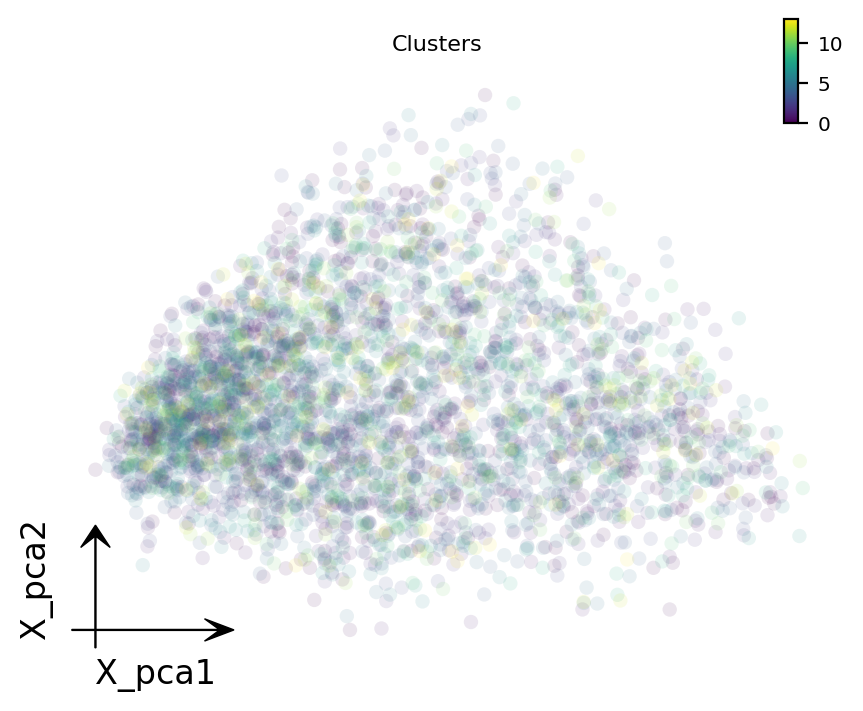

In [14]:
dyn.pl.pca(adata, color='Clusters',pointsize=0.1)

In [ ]:
adata.write(result_path+'EG_dyn.h5ad')